<a href="https://colab.research.google.com/github/jaipriyap6-code/codsoft_tasks/blob/main/CODSOFT_Task4_Customer_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/superstore_sales_eda.csv')

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_Name,Segment,City,State,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,ORD0019,2023-01-09,Rohit,Consumer,Jaipur,Rajasthan,Technology,Printers,Printers Product 3,1358.52,1,0.00,310.31
1,ORD0186,2023-01-12,Manoj,Consumer,Chennai,Tamil Nadu,Office Supplies,Storage,Storage Product 14,944.87,4,0.10,168.08
2,ORD0166,2023-01-12,Amit,Corporate,Jaipur,Rajasthan,Office Supplies,Binders,Binders Product 14,163.68,5,0.00,11.19
3,ORD0138,2023-01-12,Meena,Consumer,Bangalore,Karnataka,Office Supplies,Paper,Paper Product 20,553.59,5,0.00,34.15
4,ORD0048,2023-01-12,Meena,Consumer,Jaipur,Rajasthan,Office Supplies,Binders,Binders Product 16,367.50,1,0.15,36.62


In [ ]:
df['Customer_Name'].nunique()

20

In [ ]:
df['Customer_Name'].value_counts().head(10)

,count
Customer_Name,
Meena,16
Priya,14
Arun,13
Sneha,12
Kiran,12
Divya,12
Pooja,11
Vikram,11
Lakshmi,10


In [ ]:
df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Customer_Name,
Arun,22270.24
Meena,21293.50
Priya,19643.96
Divya,18930.21
Sneha,17680.25
Asha,16749.62
Amit,16150.18
Neha,16147.96
Manoj,15965.13


In [ ]:
df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
Customer_Name,
Meena,2885.21
Divya,2605.54
Manoj,2404.86
Priya,2309.02
Amit,2068.32
Neha,2045.73
Arun,1853.25
Asha,1680.85
Vikram,1634.09


In [ ]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,160935.47
Corporate,84573.29
Home Office,32728.28


In [ ]:
df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

,Profit
Segment,
Consumer,15785.42
Corporate,11308.71
Home Office,3638.05


Customer purchasing behavior by Category

In [ ]:
df.groupby(['Segment', 'Category'])['Sales'].sum()

Segment      Category       
Consumer     Furniture          51335.59
             Office Supplies    30254.29
             Technology         79345.59
Corporate    Furniture          32898.24
             Office Supplies     9403.51
             Technology         42271.54
Home Office  Furniture          13118.59
             Office Supplies     6838.15
             Technology         12771.54
Name: Sales, dtype: float64

Customer analysis by Location

In [ ]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False)

,Sales
City,
Chennai,39696.54
Mumbai,35268.07
Jaipur,35227.55
Pune,30468.32
Bangalore,29842.24
Kochi,29249.53
Delhi,26185.25
Hyderabad,22906.34
Ahmedabad,18240.13


Most profitable locations

In [ ]:
df.groupby('City')['Profit'].sum().sort_values(ascending=False)

,Profit
City,
Jaipur,4597.05
Mumbai,4405.44
Chennai,3710.82
Delhi,3435.16
Hyderabad,3052.13
Pune,2884.64
Kochi,2723.62
Bangalore,2563.74
Ahmedabad,2467.84


Find the Top 10 Most Valuable Customers

In [ ]:
customer_summary = df.groupby('Customer_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order_ID', 'count'))
customer_summary.sort_values('Total_Sales', ascending=False).head(10)

,Total_Sales,Total_Profit,Total_Orders
Customer_Name,,,
Arun,22270.24,1853.25,13
Meena,21293.50,2885.21,16
Priya,19643.96,2309.02,14
Divya,18930.21,2605.54,12
Sneha,17680.25,1632.42,12
Asha,16749.62,1680.85,10
Amit,16150.18,2068.32,10
Neha,16147.96,2045.73,9
Manoj,15965.13,2404.86,9


Top 10 Customers by Profit

In [ ]:
customer_summary.sort_values('Total_Profit', ascending=False).head(10)

,Total_Sales,Total_Profit,Total_Orders
Customer_Name,,,
Meena,21293.50,2885.21,16
Divya,18930.21,2605.54,12
Manoj,15965.13,2404.86,9
Priya,19643.96,2309.02,14
Amit,16150.18,2068.32,10
Neha,16147.96,2045.73,9
Arun,22270.24,1853.25,13
Asha,16749.62,1680.85,10
Vikram,14382.55,1634.09,11


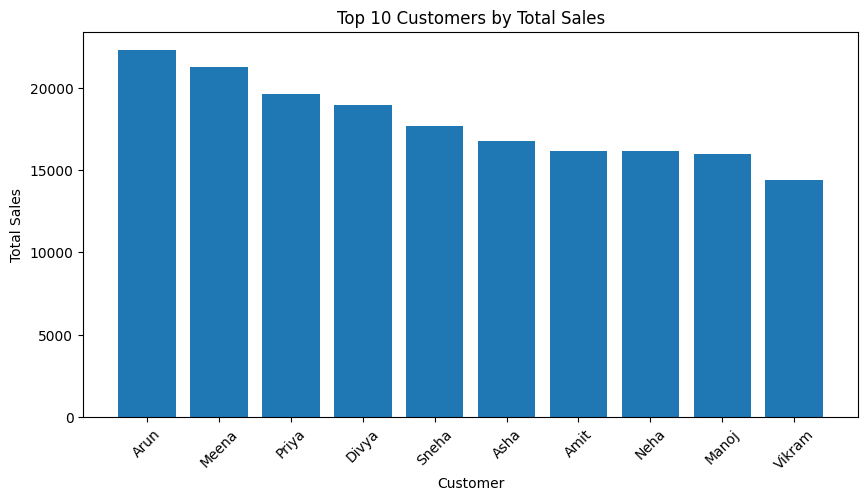

In [ ]:
plt.figure(figsize=(10,5))
top_customers = customer_summary.sort_values(
    'Total_Sales', ascending=False
).head(10)



plt.bar(top_customers.index, top_customers['Total_Sales'])

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

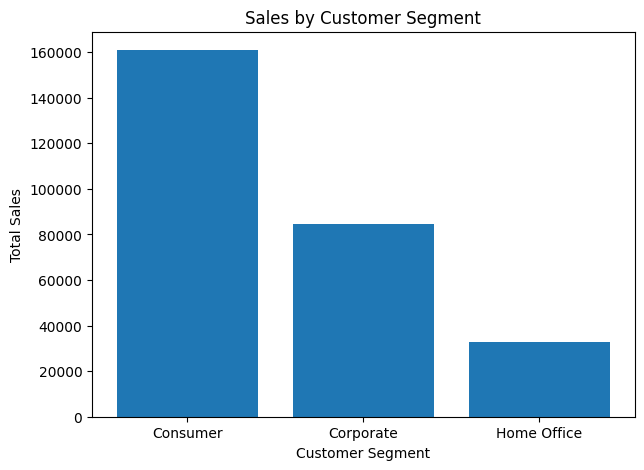

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,5))

plt.bar(segment_sales.index, segment_sales.values)

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

plt.show()